In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# makes plots look cleaner in notebooks
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries loaded succesfully")


Libraries loaded succesfully


In [3]:
# Load all datasets
orders = pd.read_csv('../data/raw/olist_orders_dataset.csv')
items = pd.read_csv('../data/raw/olist_order_items_dataset.csv')
products = pd.read_csv('../data/raw/olist_products_dataset.csv')
payments = pd.read_csv('../data/raw/olist_order_payments_dataset.csv')
categories = pd.read_csv('../data/raw/product_category_name_translation.csv')

print(f"Orders: {orders.shape[0]:,} rows, {orders.shape[1]} columns")
print(f"Items: {items.shape[0]:,} rows, {items.shape[1]} columns")
print(f"Product: {products.shape[0]:,} rows, {products.shape[1]} columns")

Orders: 99,441 rows, 8 columns
Items: 112,650 rows, 7 columns
Product: 32,951 rows, 9 columns


In [6]:
# Columns each table has
for name, df in [('orders', orders), ('items', items), ('products', products)]:
    print(f"\n[{'='*50}")
    print(f"TABLE: {name}")
    print(f"{'='*50}")
    print(df.dtypes)


[==================================================
TABLE: orders
order_id                         str
customer_id                      str
order_status                     str
order_purchase_timestamp         str
order_approved_at                str
order_delivered_carrier_date     str
order_delivered_customer_date    str
order_estimated_delivery_date    str
dtype: object

[==================================================
TABLE: items
order_id                   str
order_item_id            int64
product_id                 str
seller_id                  str
shipping_limit_date        str
price                  float64
freight_value          float64
dtype: object

[==================================================
TABLE: products
product_id                        str
product_category_name             str
product_name_lenght           float64
product_description_lenght    float64
product_photos_qty            float64
product_weight_g              float64
product_length_cm            

### Table Relationship
- 'orders' connects to 'items' via order_id
- 'items' connects to 'products' via product_id

In [11]:
# DATA QUALITY CHECK
# Check for missing values across all tables
print("MISSING VALUES")
print("="*50)
for name, df in [('orders', orders), ('items', items), ('products', products)]:
    missing = df.isnull().sum()
    missing_pct = (missing / len(df) * 100).round(1)
    missing_report = pd.DataFrame({
        'missing_count': missing,
        'missing_pct': missing_pct
    })
    # only show columns that actually have missing values
    missing_report = missing_report[missing_report['missing_count'] > 0]
    if len(missing_report) > 0:
        print(f"\n{name}:")
        print(missing_report)
    else:
        print(f"\n{name}: No missing values")

MISSING VALUES

orders:
                               missing_count  missing_pct
order_approved_at                        160          0.2
order_delivered_carrier_date            1783          1.8
order_delivered_customer_date           2965          3.0

items: No missing values

products:
                            missing_count  missing_pct
product_category_name                 610          1.9
product_name_lenght                   610          1.9
product_description_lenght            610          1.9
product_photos_qty                    610          1.9
product_weight_g                        2          0.0
product_length_cm                       2          0.0
product_height_cm                       2          0.0
product_width_cm                        2          0.0


In [13]:
# PARSE DATES AND BUILD THE TIMELINE
# Convert date columns
date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col])

# date range
print(f"First order: {orders['order_purchase_timestamp'].min()}")
print(f"Last order: {orders['order_purchase_timestamp'].max()}")
print(f"Time span: {(orders['order_purchase_timestamp'].max() - orders['order_purchase_timestamp'].min()).days} days")

First order: 2016-09-04 21:15:19
Last order: 2018-10-17 17:30:18
Time span: 772 days


In [15]:
# MERGE TABLES INTO ONE ANALYSIS_READY DATAFRAME

# Merge items with product info
df = items.merge(products, on='product_id', how='left')

# Translate category names to English
df = df.merge(categories, on='product_category_name', how='left')

# Bring in order-level info (dates,status)
df = df.merge(orders, on='order_id', how='left')

print(f"Merged dataset: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"\nColumns: {list(df.columns)}")

Merged dataset: 112,650 rows, 23 columns

Columns: ['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'product_category_name_english', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']


In [20]:
# FILTER ONLY DELIVERED ORDER

# Check order distribution

print("Order status breakdown:")
print(df['order_status'].value_counts())
print(f"\nPercentage delivered: {(df['order_status'] == 'delivered').mean():.1%}")

# keep delivered item

df = df[df['order_status'] == 'delivered'].copy()
print(f"\nAfter filtering: {df.shape[0]:,} rows")


Order status breakdown:
order_status
delivered    110197
Name: count, dtype: int64

Percentage delivered: 100.0%

After filtering: 110,197 rows


In [22]:
# CREATE TIME FEATURES

# Extract useful time features from purchase date
df['order_date'] = df['order_purchase_timestamp'].dt.date
df['order_month'] = df['order_purchase_timestamp'].dt.to_period('M')
df['order_dayofweek'] = df['order_purchase_timestamp'].dt.day_of_week
df['order_hour'] = df['order_purchase_timestamp'].dt.hour

# map days number to name
day_names = {0:'Monday', 1:'Tuesday', 2:'Wednesday', 3:'Thursday', 4:'Friday', 5:'Saturday', 6:'Sunday'}
df['day_name'] = df['order_dayofweek'].map(day_names)

print("Time features created")
print(f"Sample:\n{df[['order_purchase_timestamp', 'order_month', 'day_name', 'order_hour']].head()}")

Time features created
Sample:
  order_purchase_timestamp order_month   day_name  order_hour
0      2017-09-13 08:59:02     2017-09  Wednesday           8
1      2017-04-26 10:53:06     2017-04  Wednesday          10
2      2018-01-14 14:33:31     2018-01     Sunday          14
3      2018-08-08 10:00:35     2018-08  Wednesday          10
4      2017-02-04 13:57:51     2017-02   Saturday          13


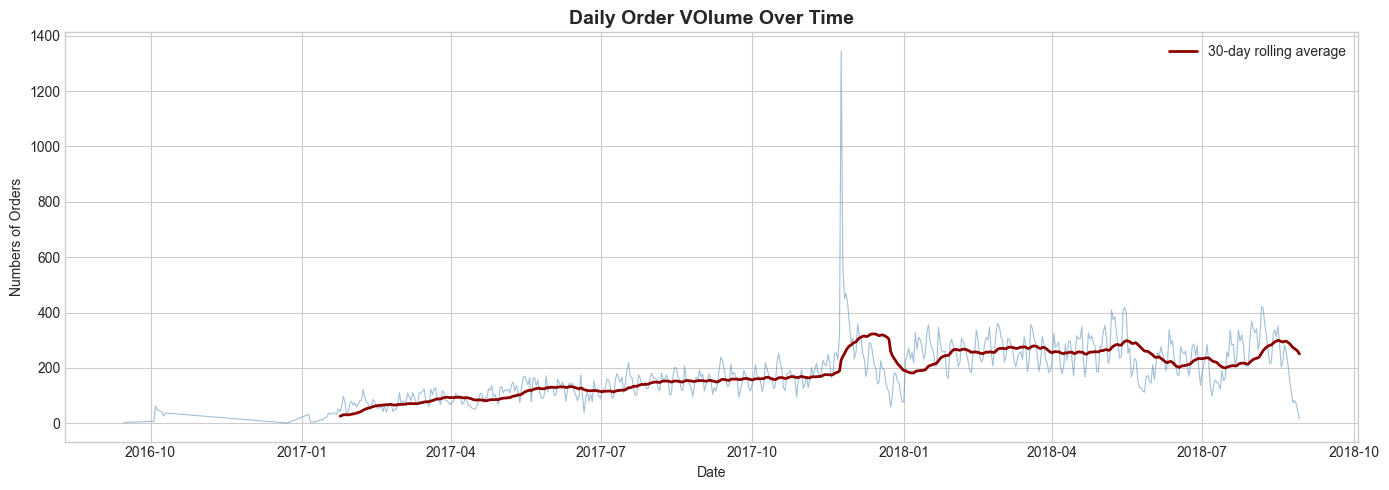

In [25]:
# PLOT ORDER VOLUME OVER TIME

# Daily order volume
daily_orders = df.groupby('order_date').size().reset_index(name='order_count')
daily_orders['order_date'] = pd.to_datetime(daily_orders['order_date'])

fig, ax = plt.subplots(figsize= (14, 5))
ax.plot(daily_orders['order_date'], daily_orders['order_count'],
        alpha=0.5, linewidth=0.8, color='steelblue')

# Add a 30-day rolling average to see the trend
rolling_avg = daily_orders['order_count'].rolling(window=30).mean()
ax.plot(daily_orders['order_date'], rolling_avg,
        color='darkred', linewidth=2, label='30-day rolling average')

ax.set_title('Daily Order VOlume Over Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Numbers of Orders')
ax.legend()
plt.tight_layout()
plt.savefig('../output/daily_order_volume.png', dpi=150, bbox_inches='tight')
plt.show()

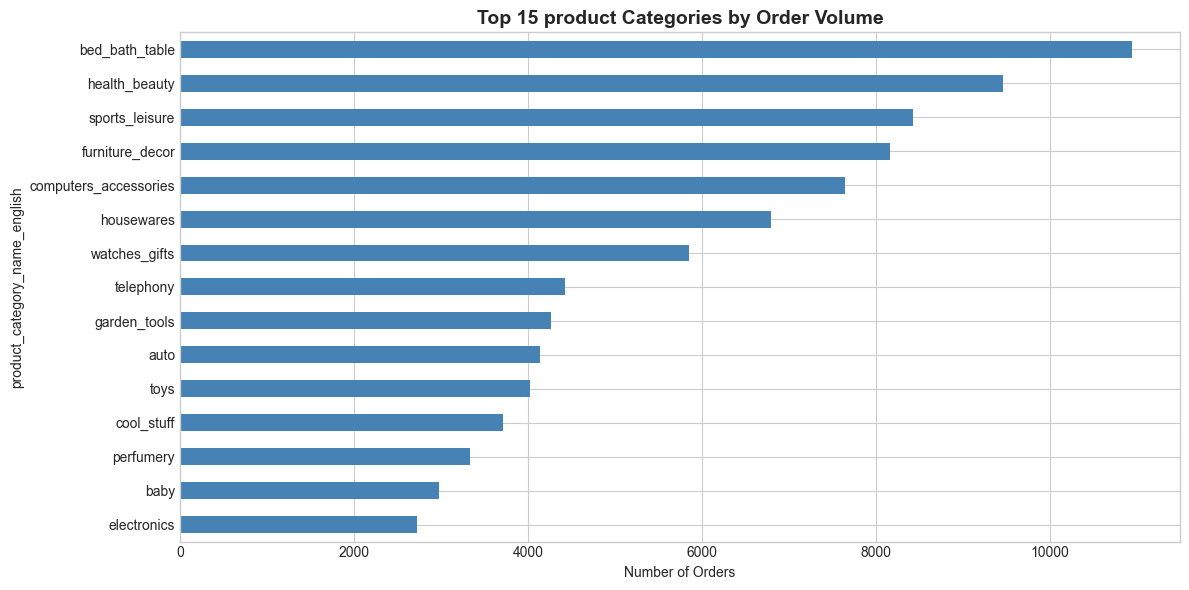

In [28]:
# TOP PRODUCT CATEGORIES

# Top 15 Categories by order volume
top_categories = (df['product_category_name_english']
                  .value_counts()
                  .head(15))

fig, ax = plt.subplots(figsize=(12, 6))
top_categories.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 15 product Categories by Order Volume', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Orders')
ax.invert_yaxis() # highest at top
plt.tight_layout()
plt.savefig('../output/top_categories.png', dpi=150, bbox_inches='tight')
plt.show()

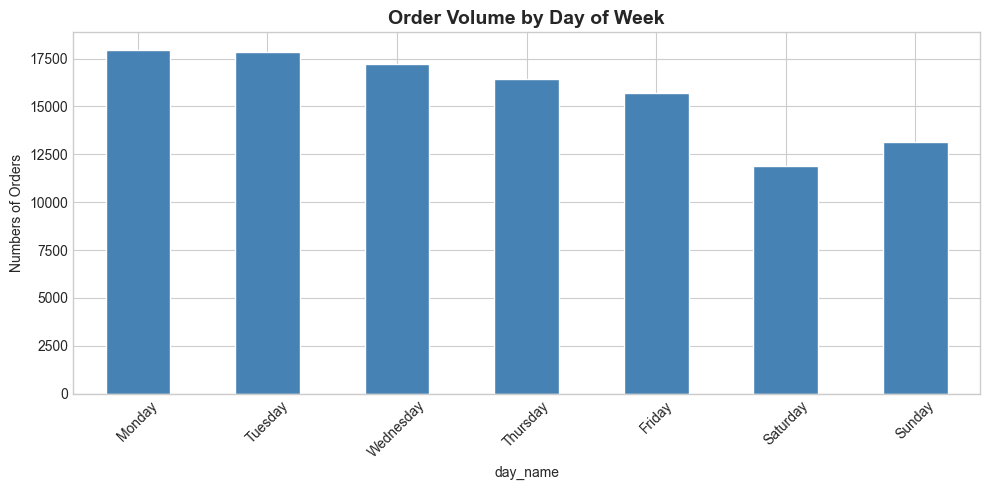

In [30]:
# WEEKLY PATTERNS

#Order volume by day of week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_pattern = df['day_name'].value_counts().reindex(day_order)

fig, ax = plt.subplots(figsize=(10,5))
daily_pattern.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Order Volume by Day of Week', fontsize=14, fontweight='bold')
ax.set_ylabel('Numbers of Orders')
ax.set_xticklabels(day_order, rotation=45)
plt.tight_layout()
plt.savefig('../output/orders_by_day.png', dpi=150, bbox_inches='tight')
plt.show()

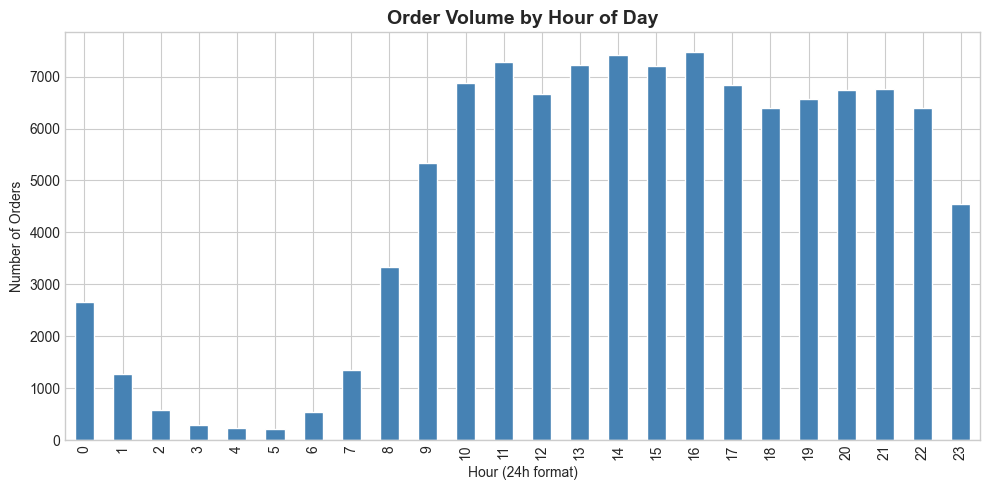

In [31]:
#Hourly patterns

# Order Volume by hour
hourly_pattern = df['order_hour'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 5))
hourly_pattern.plot(kind='bar', ax = ax, color='steelblue', edgecolor='white')
ax.set_title('Order Volume by Hour of Day', fontsize=14, fontweight='bold')
ax.set_xlabel('Hour (24h format)')
ax.set_ylabel('Number of Orders')
plt.tight_layout()
plt.savefig('../output/orders_by_hour.png', dpi=150, bbox_inches='tight')
plt.show()

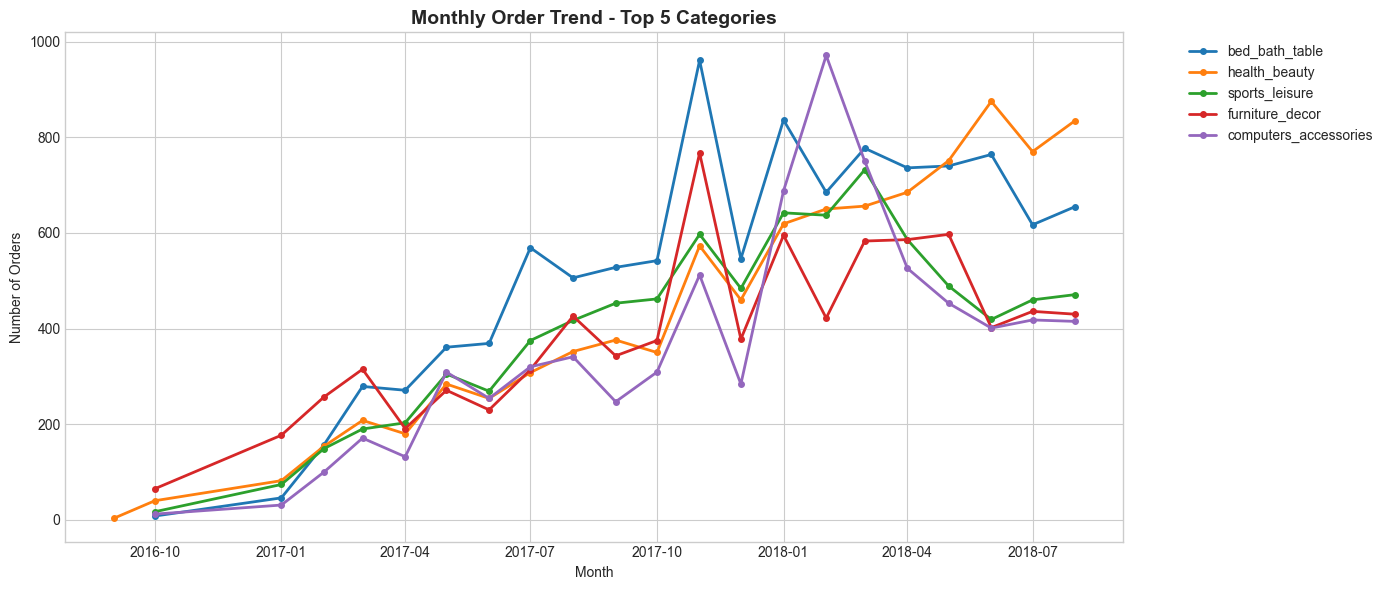

In [34]:
# MONTHLY TREND BY TOP CATEGORIES

# top 5 categories
top5 = df['product_category_name_english'].value_counts().head(5).index.tolist()

# filter and group
monthly_by_cat = (df[df['product_category_name_english'].isin(top5)]
                  .groupby([df['order_purchase_timestamp'].dt.to_period('M'),
                            'product_category_name_english'])
                            .size()
                            .reset_index(name='order_count'))

monthly_by_cat.columns = ['month', 'category', 'order_count']
monthly_by_cat['month'] = monthly_by_cat['month'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 6))
for cat in top5:
    cat_data = monthly_by_cat[monthly_by_cat['category'] == cat]
    ax.plot(cat_data['month'], cat_data['order_count'], marker='o',
            markersize=4, linewidth=2, label=cat)
    
ax.set_title('Monthly Order Trend - Top 5 Categories', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Orders')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('../output/monthly_trend_top5.png', dpi=150, bbox_inches='tight')
plt.show()

## EDA Summary - Key Findings

1. **Dataset**: ~110k delivered orders across 2 years (Sep 2016 - Oct 2018)
2. **Growth**: demand steadily growing over the year. Trend down little bit in 2018 but slowly recover by the end of the year.
3. **Seasonality**: Spike during end of the year suspected for promotional campaign of black_friday which customer take advantage of the low price especially for bed bat table and furniture decor. Health Beauty show steady demand growth. Computers accessories show huge spike during january-february. 
4. **Top Categories**: The top categories are 1) bed bath table 2) health beauty 3)sports leisure 4)furniture decor 5) computers accessories
5. **Weekly Pattern**: Monday and Tuesday becoming the busiest day in the week
6. **Hourly Pattern**: People order the most between 10 am until 10 pm
7. **Data Quality**: Missing values are minimal (<3%), mostly from undelivered orders

## Implication for forecasting
- The model needs to capture weekly seasonality (Mon/Tue peaks)
- The model needs to capture yearly seasonality (Q4 spikes)
- The model needs to account for overall growth trend
- Categories behave differently = we should build separate models per category


In [35]:
# Select columns we'll need for forecasting
forecast_df = df[['order_id', 'order_purchase_timestamp', 'order_date',
                  'order_month', 'order_dayofweek', 'day_name', 'order_hour',
                  'product_id', 'product_category_name_english',
                  'price', 'freight_value']].copy()

# Drop rows with missing category
forecast_df = forecast_df.dropna(subset=['product_category_name_english'])

print(f"Forecast-ready dataset: {forecast_df.shape[0]:,} rows")
forecast_df.to_csv('../data/processed/forecast_ready.csv', index=False)
print("Saved to data/processed/forecast_ready.csv ✓")

Forecast-ready dataset: 108,638 rows
Saved to data/processed/forecast_ready.csv ✓
